#Etapas do Projeto:

**1- O problema de negócio:** objetivo principal do projeto e como ele gera valor ao banco.

**2- Coleta e entendimento dos dados:** subir no github e validar importação.

**3- Dividir os dados em conjuntos de treino e teste:** Separar uma parte dos dados para ensinar o algoritmo e outra parte isolada para validar sua capacidade de generalização.

**4- Análise exploratória de dados - EDA:** Identificar padrões visuais, distribuições, outliers e entender como as variáveis se relacionam com o alvo.

**5- Engenharia de features, limpeza de dados e pré-processamento:** Tratar valores nulos, codificar categorias e criar novas variáveis calculadas para facilitar o aprendizado do algoritmo.

**6- Treinamento do modelo, comparação, seleção de features e ajuste (tuning):** Testar diferentes algoritmos, selecionar as colunas mais importantes e otimizar os hiperparâmetros para obter a melhor performance.

**7- Teste e Avaliação Final do Modelo** (Hold-out Validation)

**8 - Concluir e interpretar os resultados do modelo:** Explicar as decisões do algoritmo (usando técnicas como valores SHAP) para entender o que impulsiona o comportamento mapeado.

**9- Implantação (Deploy):** Colocar o modelo em produção via API ou web app (ou, no contexto de uma competição, gerar e submeter o arquivo final de predições).


## Observações:
Essas Etapas foram definidas, tomando como base a métodologia CRISP-DM.

Esse Notebook contém a execução das etapas 5 até 8 relacionadas a modelagem. As analises feitas aqui vizam aplicar a desde a engenharia de fetuares, escolha e comparação de modelos, e por fim concluir qual tem melhor resultado para o nosso problema (Detecção de Churn).

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Instalações e Dependências

In [3]:
!pip install catboost optuna shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 21.4 MB/s eta 0:00:00


In [4]:
# 1. Configurações Globais
import warnings
warnings.filterwarnings('ignore')

# 2. Manipulação de Dados e Visualização
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# 3. Pré-processamento, Validação e Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.pipeline import Pipeline

# 4. Modelos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool

# 5. Otimização (Tuning)
import optuna

# 6. Métricas e XAI (Interpretabilidade)
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, recall_score, f1_score, accuracy_score, precision_score
import shap

## Coleta de Dados

In [5]:
# URLs (raw) do repositório no GitHub
# Dados de treino para o modelo
url_train = "https://raw.githubusercontent.com/GabrielSenkovski/Bank_Churn_Model/refs/heads/main/Datasets/train.csv"

# DataFrame
df_dados = pd.read_csv(url_train)

# Imprimindo shape
print(f"Dataset de Treino carregado com sucesso: {df_dados.shape[0]} linhas e {df_dados.shape[1]} colunas.")

# Visualizando as primeiras linhas do conjunto de treino
display(df_dados.head())

Dataset de Treino carregado com sucesso: 15000 linhas e 14 colunas.


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15634591.0,Pagnotto,775.0,France,Male,29.0,4.0,0.00,2.0,1.0,0.0,61315.37,0.0
1,1,15584364.0,Aksenov,599.0,Spain,Female,38.0,7.0,0.00,2.0,1.0,0.0,180622.01,0.0
2,2,15662854.0,Y?an,602.0,France,Male,45.0,5.0,0.00,2.0,1.0,0.0,173989.66,0.0
3,3,15726153.0,Lai,775.0,France,Male,42.0,7.0,89158.84,1.0,1.0,1.0,180698.32,0.0
4,4,15743193.0,Chukwuebuka,663.0,Germany,Male,39.0,2.0,129663.49,1.0,0.0,1.0,172363.41,0.0


In [6]:
# Criando uma cópia para preservar o dado original em caso de erro
df_model = df_dados.copy()

# Removendo variáveis de identificação que não geram valor preditivo
colunas_para_dropar = ['id', 'CustomerId', 'Surname']
df_model.drop(columns=colunas_para_dropar, inplace=True)
# Verifica Colunas Restantes
print(f"Colunas restantes para análise: {df_model.columns.tolist()}")


Colunas restantes para análise: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


## Divisão de X e y, Treino e Teste Estratificados

In [7]:
# Definindo X e y
X = df_model.drop(columns='Exited')
y = df_model['Exited']

# Definindo Treino e Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [8]:
# Verificando numero linhas e colunas
print("Tamanho de X_train:", X_train.shape)
print("Tamanho de X_test:", X_test.shape, "\n")

# Testando a estratificação (a porcentagem de 0s e 1s deve ser idêntica nos dois grupos)
print("Proporção de Churn no Treino:")
print(y_train.value_counts(normalize=True) * 100)

print("\nProporção de Churn no Teste:")
print(y_test.value_counts(normalize=True) * 100)

Tamanho de X_train: (12000, 10)
Tamanho de X_test: (3000, 10) 

Proporção de Churn no Treino:
Exited
0.0    79.516667
1.0    20.483333
Name: proportion, dtype: float64

Proporção de Churn no Teste:
Exited
0.0    79.5
1.0    20.5
Name: proportion, dtype: float64


# Etapa 5: Engenharia de Features e Pré-processamento

Objetivo: Traduzir os insights da Análise Exploratória (EDA) em variáveis matemáticas e preparar os dados limpos para os algoritmos.

### 1. Novas Variáveis de Negócio (EngenheiroFeaturesChurn)
Criamos novas métricas focadas em identificar o comportamento de evasão:

* **Active_vs_Products:** Cruza o status de atividade com o volume de produtos contratados.
* **Balance_Salary_Ratio:** Calcula qual porcentagem da renda anual do cliente está guardada no banco.
* **Age_Risk_Zone:** Segmenta as idades em faixas de risco baseadas na distribuição histórica.
* **Is_High_Balance_Leak / Product_Danger_Zone / German_Risk_Persona:** Flags numéricas de alerta (0 ou 1) que isolam os perfis mais críticos descobertos na EDA.

Decisão de Arquitetura (Tipagem): Forçamos todas as variáveis categóricas (originais e novas) para o tipo String. Essa técnica de programação defensiva garante que o CatBoost faça a leitura nativa do texto, evitando erros estruturais no momento do treinamento.

---

### 2. Estratégia de Processamento Duplo
Para extrair a máxima performance sem enviesar a competição, criamos duas pipelines separadas para o pré-processamento dos dados:

* **Processador com OHE (processador_com_ohe):** Aplica StandardScaler nas numéricas e OneHotEncoder nas categóricas. É focado nos modelos clássicos (Regressão Logística, Random Forest, XGBoost) que não leem texto e exigem a quebra das categorias em matrizes binárias.
* **Processador sem OHE (processador_sem_ohe):** Aplica StandardScaler nas numéricas e mantém as categóricas inalteradas (Passthrough). É criado para o CatBoost, permitindo que o algoritmo aplique sua inteligência matemática avançada diretamente sobre o texto.

In [9]:
class EngenheiroFeaturesChurn(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_novo = X.copy()

        # Numéricas
        X_novo['Active_vs_Products'] = X_novo['IsActiveMember'] * X_novo['NumOfProducts']
        X_novo['Balance_Salary_Ratio'] = X_novo['Balance'] / (X_novo['EstimatedSalary'] + 1e-6)

        # Categóricas (Forçando tipo String para blindar o CatBoost)
        limites = [0, 30, 45, 60, 100]
        rotulos = ['Jovem', 'Adulto', 'Meia-Idade', 'Senior']
        X_novo['Age_Risk_Zone'] = pd.cut(X_novo['Age'], bins=limites, labels=rotulos).astype(str)

        X_novo['Is_High_Balance_Leak'] = ((X_novo['Balance'] > 100000) & (X_novo['Balance'] < 150000)).astype(int).astype(str)
        X_novo['Product_Danger_Zone'] = (X_novo['NumOfProducts'] >= 3).astype(int).astype(str)
        X_novo['German_Risk_Persona'] = ((X_novo['Geography'] == 'Germany') & (X_novo['IsActiveMember'] == 0)).astype(int).astype(str)

        # Garantindo que as categóricas originais também sejam strings
        cols_originais_cat = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']
        X_novo[cols_originais_cat] = X_novo[cols_originais_cat].astype(str)

        return X_novo

In [10]:
colunas_numericas = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'Active_vs_Products', 'Balance_Salary_Ratio']
colunas_categoricas = ['Geography', 'Gender', 'Age_Risk_Zone', 'HasCrCard', 'IsActiveMember', 'Is_High_Balance_Leak', 'Product_Danger_Zone', 'German_Risk_Persona']

# Processador 1: Para Modelos Clássicos (COM One-Hot Encoding)
processador_com_ohe = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), colunas_categoricas)
    ],
    remainder='drop'
).set_output(transform="pandas")

# Processador 2: Para CatBoost (SEM One-Hot Encoding)
processador_sem_ohe = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), colunas_numericas),
        ('cat', 'passthrough', colunas_categoricas)
    ],
    remainder='drop'
).set_output(transform="pandas")

## Modelo Baseline

In [11]:
# Definindo os modelos tradicionais
modelos_tradicionais = {
    'LogisticRegression': LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'),
    'RandomForestClassifier': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'XGBClassifier': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum()),
    'LGBMClassifier': LGBMClassifier(random_state=42, class_weight='balanced')
}

# Configuração da Validação Cruzada (5 folds estratificados)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = []

print("Iniciando a avaliação dos modelos \n")

# Avaliação dos Modelos Clássicos (Branch B: com One Hot Encoder)
for nome, modelo in modelos_tradicionais.items():
    pipeline_classico = Pipeline(steps=[
        ('engenharia', EngenheiroFeaturesChurn()),
        ('processador', processador_com_ohe),
        ('classificador', modelo)
    ])

    cv_scores = cross_validate(pipeline_classico, X_train, y_train, cv=skf,
                               scoring=('accuracy','roc_auc', 'recall', 'f1', 'precision'), n_jobs=-1)

    resultados.append({
        'Modelo': nome,
        'accuracy_score': np.mean(cv_scores['test_accuracy']),
        'ROC-AUC': np.mean(cv_scores['test_roc_auc']),
        'Recall': np.mean(cv_scores['test_recall']),
        'F1-Score': np.mean(cv_scores['test_f1']),
        'precision_score': np.mean(cv_scores['test_precision'])
    })
    print(f" {nome} avaliado.")


Iniciando a avaliação dos modelos 

 LogisticRegression avaliado.
 RandomForestClassifier avaliado.
 XGBClassifier avaliado.
 LGBMClassifier avaliado.


In [12]:
# Avaliação do CatBoost (Branch A: Sem OHE)
# Preparação para mapear os nomes exatos das colunas categóricas no processador 'passthrough'
engenheiro = EngenheiroFeaturesChurn()
X_train_eng = engenheiro.fit_transform(X_train)
X_train_cat = processador_sem_ohe.fit_transform(X_train_eng)
cat_features_finais = [col for col in X_train_cat.columns if col.startswith('cat__')]

modelo_catboost = CatBoostClassifier(auto_class_weights='Balanced', random_state=42, verbose=0)

pipeline_catboost = Pipeline(steps=[
    ('engenharia', EngenheiroFeaturesChurn()),
    ('processador', processador_sem_ohe),
    ('classificador', modelo_catboost)
])

# Passa cat_features diretamente via 'params' no cross_validate
cv_scores_cat = cross_validate(
    pipeline_catboost,
    X_train,
    y_train,
    cv=skf,
    scoring=('accuracy','roc_auc', 'recall', 'f1', 'precision'),
    n_jobs=-1,
    params={'classificador__cat_features': cat_features_finais}
)

resultados.append({
    'Modelo': 'CatBoost',
    'accuracy_score': np.mean(cv_scores_cat['test_accuracy']),
    'ROC-AUC': np.mean(cv_scores_cat['test_roc_auc']),
    'Recall': np.mean(cv_scores_cat['test_recall']),
    'F1-Score': np.mean(cv_scores_cat['test_f1']),
    'precision_score': np.mean(cv_scores_cat['test_precision'])
})
print("CatBoost avaliado.\n")

CatBoost avaliado.



In [13]:


# Exibição do Ranking Final
df_resultados = pd.DataFrame(resultados).sort_values(by='ROC-AUC', ascending=False).reset_index(drop=True);

# Formatando a tabela visualmente para facilitar a comparação
df_styled = df_resultados.style.highlight_max(
    subset=['accuracy_score','ROC-AUC', 'Recall', 'F1-Score', 'precision_score'],
    color='rgba(144, 238, 144, 0.4)', # Verde opaco
    axis=0
).format("{:.3f}", subset=['accuracy_score','ROC-AUC', 'Recall', 'F1-Score', 'precision_score']);



print("Ranking Final dos Modelos (Baseline):");
display(df_styled);

Ranking Final dos Modelos (Baseline):


,Modelo,accuracy_score,ROC-AUC,Recall,F1-Score,precision_score
0,CatBoost,0.865,0.927,0.816,0.712,0.632
1,LogisticRegression,0.852,0.924,0.844,0.700,0.598
2,LGBMClassifier,0.870,0.923,0.810,0.718,0.646
3,RandomForestClassifier,0.891,0.919,0.634,0.704,0.792
4,XGBClassifier,0.873,0.911,0.756,0.709,0.668


In [14]:


#  Mapeamento Dinâmico
cat_features_finais = [col for col in X_train_cat.columns if col.startswith('cat__')]

# Criando o X_test_cat (Resolvendo o seu NameError)
X_test_eng = engenheiro.transform(X_test)
X_test_cat = processador_sem_ohe.transform(X_test_eng)

# 2. Pool Otimizado
pool_treino = Pool(
    data=X_train_cat,
    label=y_train,
    cat_features=cat_features_finais
)

# Seletor focado em AUC
modelo_seletor = CatBoostClassifier(
    auto_class_weights='Balanced',
    eval_metric='AUC',
    random_state=42,
    verbose=0
)

# Execução da Seleção (Ajustado)
print("Iniciando Seleção Recursiva de Features via SHAP Values...")
resultado_selecao = modelo_seletor.select_features(
    pool_treino,
    features_for_select=list(X_train_cat.columns),
    num_features_to_select=5,              # Limite mínimo (o algoritmo tentará chegar aqui)
    steps=5,                               # Reavalia SHAP a cada 5 remoções
    algorithm='RecursiveByShapValues',
    # features_to_drop_count removido (causador do erro)
    train_final_model=False,
    plot=True
)

# Resgate das Features
features_selecionadas = resultado_selecao['selected_features_names']

print(f"Seleção Concluída!")
print(f"--- Variáveis Mantidas ({len(features_selecionadas)}): {features_selecionadas}")

# Filtragem das Bases (Criação do X_test_final que faltava no bloco anterior)
X_train_final = X_train_cat[features_selecionadas]
X_test_final = X_test_cat[features_selecionadas]

Iniciando Seleção Recursiva de Features via SHAP Values...


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Learning rate set to 0.029768
Step #1 out of 5
Feature #15 eliminated
Feature #13 eliminated
Feature #14 eliminated
Step #2 out of 5
Feature #11 eliminated
Feature #12 eliminated
Feature #2 eliminated
Step #3 out of 5
Feature #7 eliminated
Feature #10 eliminated
Step #4 out of 5
Feature #9 eliminated
Feature #5 eliminated
Step #5 out of 5
Feature #8 eliminated


Seleção Concluída!
--- Variáveis Mantidas (5): ['num__CreditScore', 'num__Age', 'num__Balance', 'num__NumOfProducts', 'num__Active_vs_Products']


In [15]:
# Lista definitiva de features (Removendo as 3 ruidosas identificadas no gráfico)
# Mantemos as numéricas e as categóricas estáveis
features_finais = [
    # Numéricas
    'num__CreditScore', 'num__Age', 'num__Tenure', 'num__Balance',
    'num__NumOfProducts', 'num__EstimatedSalary', 'num__Active_vs_Products',
    'num__Balance_Salary_Ratio',
    # Categóricas (Filtradas)
    'cat__Geography', 'cat__Gender', 'cat__Age_Risk_Zone',
    'cat__HasCrCard', 'cat__IsActiveMember'
]

# Filtragem das bases
X_train_final = X_train_cat[features_finais]
X_test_final = X_test_cat[features_finais]

# Identificação das categóricas para o CatBoost
cat_features_tuning = [col for col in features_finais if col.startswith('cat__')]

print(f"Setup concluído. {len(features_finais)} variáveis selecionadas.")
print(f"Categorias para o modelo: {cat_features_tuning}")

Setup concluído. 13 variáveis selecionadas.
Categorias para o modelo: ['cat__Geography', 'cat__Gender', 'cat__Age_Risk_Zone', 'cat__HasCrCard', 'cat__IsActiveMember']


## Tuning

In [16]:
def objective(trial):
    # Espaço de busca (Hiperparâmetros)
    params = {
        "iterations": 500,
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.05, log=True),
        "depth": trial.suggest_int("depth", 4, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "random_strength": trial.suggest_float("random_strength", 0.1, 2.0),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "border_count": trial.suggest_int("border_count", 128, 255),
        "auto_class_weights": "Balanced",
        "eval_metric": "AUC",
        "random_state": 42,
        "verbose": False,
        "allow_writing_files": False # Evita criar arquivos de log em cada trial
    }

    # 2. Configuração da Validação Cruzada Manual (Resolve o erro de clonagem)
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []

    # O loop manual não tenta clonar o objeto, ele apenas treina instâncias novas
    for train_idx, val_idx in skf.split(X_train_final, y_train):
        # Separação dos dados do fold
        X_fold_train, X_fold_val = X_train_final.iloc[train_idx], X_train_final.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        # Criação do modelo dentro do fold
        model = CatBoostClassifier(**params)

        # Treinamento (Passamos cat_features aqui para garantir segurança)
        model.fit(
            X_fold_train, y_fold_train,
            cat_features=cat_features_tuning,
            eval_set=(X_fold_val, y_fold_val),
            early_stopping_rounds=50,
            verbose=False
        )

        # Predição e Score
        preds = model.predict_proba(X_fold_val)[:, 1]
        auc = roc_auc_score(y_fold_val, preds)
        cv_scores.append(auc)

    return np.mean(cv_scores)

# 3. Execução do Estudo
print(" Iniciando Otimização Bayesiana com Loop Estratificado...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("\n--- RESULTADOS DO TUNING ---")
print(f"Melhor ROC-AUC Médio: {study.best_value:.4f}")
print(f"Melhores Parâmetros: {study.best_params}")

# Instantiate and train the final model with the best parameters
print("\n--- Treinando o Modelo Final ---")
modelo_final = CatBoostClassifier(
    **study.best_params,
    auto_class_weights='Balanced',
    eval_metric='AUC',
    random_state=42,
    verbose=False,
    allow_writing_files=False
)

# Modelo final
modelo_final.fit(X_train_final, y_train, cat_features=cat_features_tuning)

[I 2026-04-26 16:58:30,309] A new study created in memory with name: no-name-55330f75-90fd-453f-aee8-997682ffd28e


🚀 Iniciando Otimização Bayesiana com Loop Estratificado...


[I 2026-04-26 16:58:51,986] Trial 0 finished with value: 0.9318850175680286 and parameters: {'learning_rate': 0.022339882144302443, 'depth': 4, 'l2_leaf_reg': 6.270211339843311, 'random_strength': 0.11264537850388856, 'bagging_temperature': 0.8699187242207457, 'border_count': 154}. Best is trial 0 with value: 0.9318850175680286.
[I 2026-04-26 16:59:09,311] Trial 1 finished with value: 0.931230734869286 and parameters: {'learning_rate': 0.03168610301617512, 'depth': 6, 'l2_leaf_reg': 3.510934275677155, 'random_strength': 0.35387635587442867, 'bagging_temperature': 0.5626545387208408, 'border_count': 246}. Best is trial 0 with value: 0.9318850175680286.
[I 2026-04-26 16:59:37,737] Trial 2 finished with value: 0.9313730591394137 and parameters: {'learning_rate': 0.013932838354950869, 'depth': 5, 'l2_leaf_reg': 4.938692844144891, 'random_strength': 0.4367923233503016, 'bagging_temperature': 0.6089630019210888, 'border_count': 160}. Best is trial 0 with value: 0.9318850175680286.
[I 2026-04


--- RESULTADOS DO TUNING ---
Melhor ROC-AUC Médio: 0.9319
Melhores Parâmetros: {'learning_rate': 0.022339882144302443, 'depth': 4, 'l2_leaf_reg': 6.270211339843311, 'random_strength': 0.11264537850388856, 'bagging_temperature': 0.8699187242207457, 'border_count': 154}

--- Treinando o Modelo Final ---


CatBoostClassifier(allow_writing_files=False, auto_class_weights='Balanced', bagging_temperature=0.8699187242207457, border_count=154, depth=4, eval_metric='AUC', l2_leaf_reg=6.270211339843311, learning_rate=0.022339882144302443, random_state=42, random_strength=0.11264537850388856, verbose=False)

In [17]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, classification_report

# Pegar os melhores parâmetros do seu estudo Optuna
melhores_params = study.best_params

# Adicionar os parâmetros fixos necessários
melhores_params.update({
    "iterations": 1000,
    "auto_class_weights": "Balanced",
    "eval_metric": "AUC",
    "random_state": 42,
    "verbose": 100
})

# 3. Instanciar e Treinar
modelo_final = CatBoostClassifier(**melhores_params)
modelo_final.fit(X_train_final, y_train, cat_features=cat_features_tuning)

# 4. Validar no Teste
probas = modelo_final.predict_proba(X_test_final)[:, 1]
auc_teste = roc_auc_score(y_test, probas)

print(f"\n ROC-AUC FINAL NO TESTE: {auc_teste:.4f}")

0:	total: 13ms	remaining: 13s
100:	total: 1.26s	remaining: 11.2s
200:	total: 2.6s	remaining: 10.3s
300:	total: 3.9s	remaining: 9.06s
400:	total: 6.36s	remaining: 9.5s
500:	total: 8.99s	remaining: 8.95s
600:	total: 10.3s	remaining: 6.81s
700:	total: 11.6s	remaining: 4.93s
800:	total: 12.9s	remaining: 3.21s
900:	total: 14.2s	remaining: 1.56s
999:	total: 15.6s	remaining: 0us

🚀 ROC-AUC FINAL NO TESTE: 0.9271


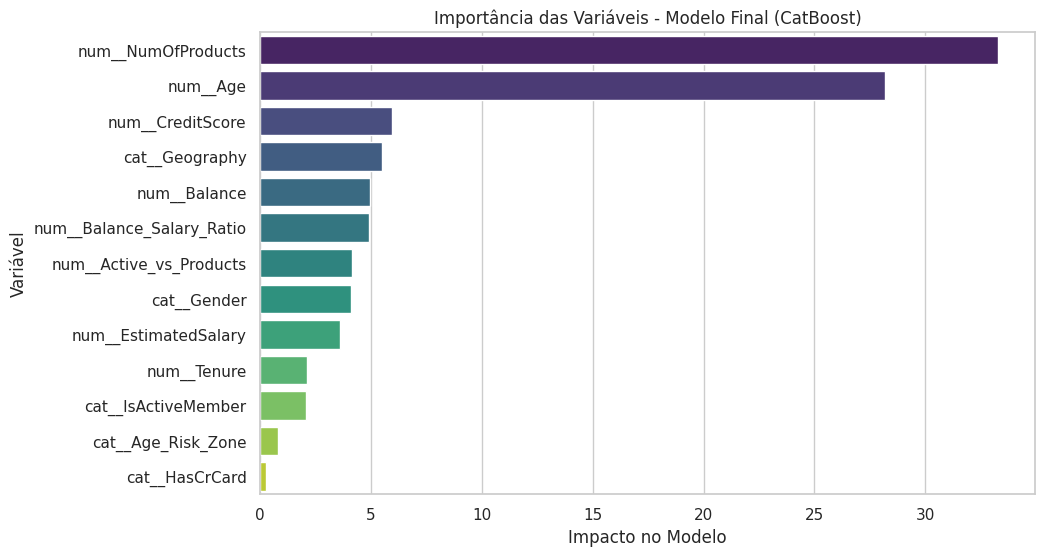

,Feature,Importance
4,num__NumOfProducts,33.271566
1,num__Age,28.199774
0,num__CreditScore,5.969849
8,cat__Geography,5.525459
3,num__Balance,4.955736
7,num__Balance_Salary_Ratio,4.905764
6,num__Active_vs_Products,4.168267
9,cat__Gender,4.104370
5,num__EstimatedSalary,3.617358
2,num__Tenure,2.125680


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extraindo a importância
feature_importance = modelo_final.get_feature_importance()
feature_names = X_train_final.columns

# Criando DataFrame para o Plot
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

# Plot Visual
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance, palette='viridis')
plt.title('Importância das Variáveis - Modelo Final (CatBoost)')
plt.xlabel('Impacto no Modelo')
plt.ylabel('Variável')
plt.show()

# Exibir tabela para conferência
display(df_importance)

<Figure size 600x500 with 0 Axes>

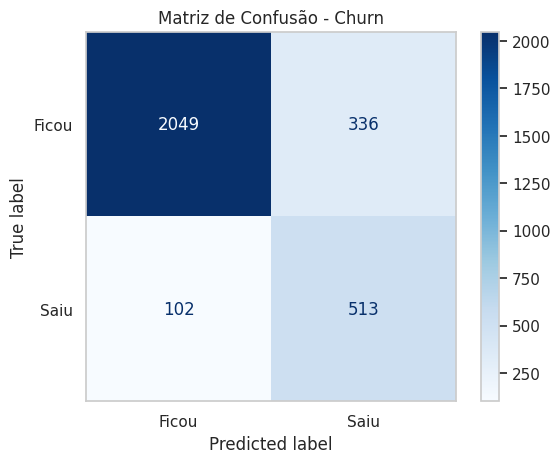

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = modelo_final.predict(X_test_final)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ficou', 'Saiu']).plot(cmap='Blues')
plt.title('Matriz de Confusão - Churn')
plt.grid(False)
plt.show()